In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [102]:
from src.data_loader import load_data
from src.forecasting.evaluation import get_prediction_errors
from src.data_quality.consistency import generate_consistency_report, print_consistency_report
from src.data_quality.completess import generate_completeness_report, print_completeness_report
from src.utils.plotting import plot_correlation_heatmap, plot_outliers, plot_predictions, plot_forecast_day
from src.models.xgboost_model import XGBoostForecaster
from src.models.randomforestregressor_model import RandomForestForecaster
from src.models.lstm_model import LSTMForecaster

## About this Dataset


### 📊 Synthetic Dataset Overview
Synthetic dataset of PV performance and associated meteorological variables for **38 sites** in the United States.  
Data sampled every **15 minutes**.  
🔗 Complete metadata available at: [Duramat Datahub](https://datahub.duramat.org/fr/dataset/metadata/synthetic-pv-performance-data)

---

### ⚡ Electricity Production Data
- 🕒 **Timestamp**: Date and time of recording (15-minute resolution).
- ⚙️ **Actual Power**: AC power measured at the inverter (without additional effects) — numerical values (e.g., kW).
- 🎯 **Reference Power**: Reference AC power including disruptive effects/losses (e.g., shading, drift, losses) — allows comparison with “ideal” production.

---

### 🌤️ Meteorological Data
- ☀️ **POA Irradiance (array tilt)**: Irradiance incident on the module plane (Plane-Of-Array), assuming correct sensor orientation (e.g., W/m²).
- 🌡️ **Ambient Temperature**: Ambient temperature (PSM3) (e.g., °C).
- 🌍 **GHI**: Global Horizontal Irradiance (PSM3) (e.g., W/m²).
- 💨 **Wind Speed**: Wind speed (PSM3) (e.g., m/s).

---



## 🎯 Study Goal
The objective this research is to predict the energy output that solar modules will generate on the following day based on the power generation data and weather measurements from the preceding day.

📝 NOTE: After a preliminary examination of both datasets, it is evident that whenever there is a significant number of missing values, the forecasting models start to strugle. As a result, I have chosen to focus exclusively on the data from plant 2 for this study, which has a more manageable 5% rate of missing values.

##  🧹📥 Load and Clean Data


This section loads the PV dataset from a CSV file and filters it to a specific time window based on the start date and duration.  
It ensures the data is timezone-aware and ready for analysis or visualization.


In [ ]:
# FILE_PATH = '/workspaces/solar_forecasting/data/interval_91_FT.csv'
FILE_PATH = '/workspaces/solar_forecasting/data/interval_41_SAT.csv'
TIMEZONE = 'UTC-08:00'
DAYS = 15
START_DATE = '2020-07-01'

### General Data

In [104]:
data = load_data(FILE_PATH)

In [105]:
# # filter data for the specified date range
start_date = pd.Timestamp(START_DATE, tz=TIMEZONE)
end_date = start_date + pd.Timedelta(days=DAYS)
data = data[(data.index >= start_date) & (data.index < end_date)]

In [106]:
power_data = data[['actual power', 'reference power']]
weather_data = data[['poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed']]

### 1 - Power generation data

In [107]:
report_consystency_power = generate_consistency_report(power_data, timestamp_col=None, expected_freq='15min', df_type='power')
print_consistency_report(report_consystency_power) 

=== Data Consistency Report ===
Detected/forced type: power
Schema used: ['actual power', 'reference power']
Missing columns: []
Extra columns: []
Dtype mismatches: 0
Duplicate index rows: 0, 
Timestamp info: {'index_is_datetime': True, 'tz': 'UTC-08:00', 'is_monotonic_increasing': True, 'inferred_freq': '15min'}
Frequency/gaps: missing=0, misaligned=0


There are no missing datetimes or columns in the dataset. All column data types match the expected formats.

In [108]:
report_completeness_power = generate_completeness_report(power_data, timestamp_col=None, expected_freq='15min')
print_completeness_report(report_completeness_power)

=== Data Completeness Report ===
Total rows present: 1440
Expected rows (range/freq): 1440
Missing timestamps: 0 (0.0%)
Duplicated index entries: 0

Per-column missingness:
 - actual power: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - reference power: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00


✅ **Conclusion**: The dataset is complete with no missing timestamps, no duplicated entries, and no missing values in the key columns.

### 2 - Weather data

In [109]:
report_consystency_weather = generate_consistency_report(weather_data, timestamp_col=None, expected_freq='15min', df_type='meteo')
print_consistency_report(report_consystency_weather) 

=== Data Consistency Report ===
Detected/forced type: meteo
Schema used: ['poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed']
Missing columns: []
Extra columns: []
Dtype mismatches: 0
Duplicate index rows: 0, 
Timestamp info: {'index_is_datetime': True, 'tz': 'UTC-08:00', 'is_monotonic_increasing': True, 'inferred_freq': '15min'}
Frequency/gaps: missing=0, misaligned=0


There are no missing datetimes or columns in the dataset. All column data types match the expected formats.

In [110]:
report_completness_weather = generate_completeness_report(weather_data, timestamp_col=None, expected_freq='15min')
print_completeness_report(report_completness_weather)

=== Data Completeness Report ===
Total rows present: 1440
Expected rows (range/freq): 1440
Missing timestamps: 0 (0.0%)
Duplicated index entries: 0

Per-column missingness:
 - poa irradiance (array tilt): 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - ambient temperature: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - ghi: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00
 - wind speed: 0 missing (0.0%), longest NaN run = 0 samples, duration = 0 days 00:00:00


✅ **Conclusion**: The dataset is complete with no missing timestamps, no duplicated entries, and no missing values in the key columns.

## Exploratory Analysis

In [111]:
# We extract more features from DATE_TIME
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek

# Convert day of year to days of our study period (1-30)
days = data.index.dayofyear
data['day'] = days.map({days.unique()[i-1]:i for i in range(1, DAYS+1)})

# Step 1: Extract time values from the index as a Series
time_series = pd.Series(data.index.time, index=data.index)

# Step 2: Get sorted unique time values
unique_times = sorted(time_series.unique())

# Step 3: Create a mapping dictionary from time to interval label (1 to 96)
time_to_interval = {t: i+1 for i, t in enumerate(unique_times)}
# Step 4: Map the time values to interval labels
data['interval'] = time_series.map(time_to_interval)

In [112]:
# use data without missing values for the moment
df_na = data[~data.isna()]

### Data Correlation

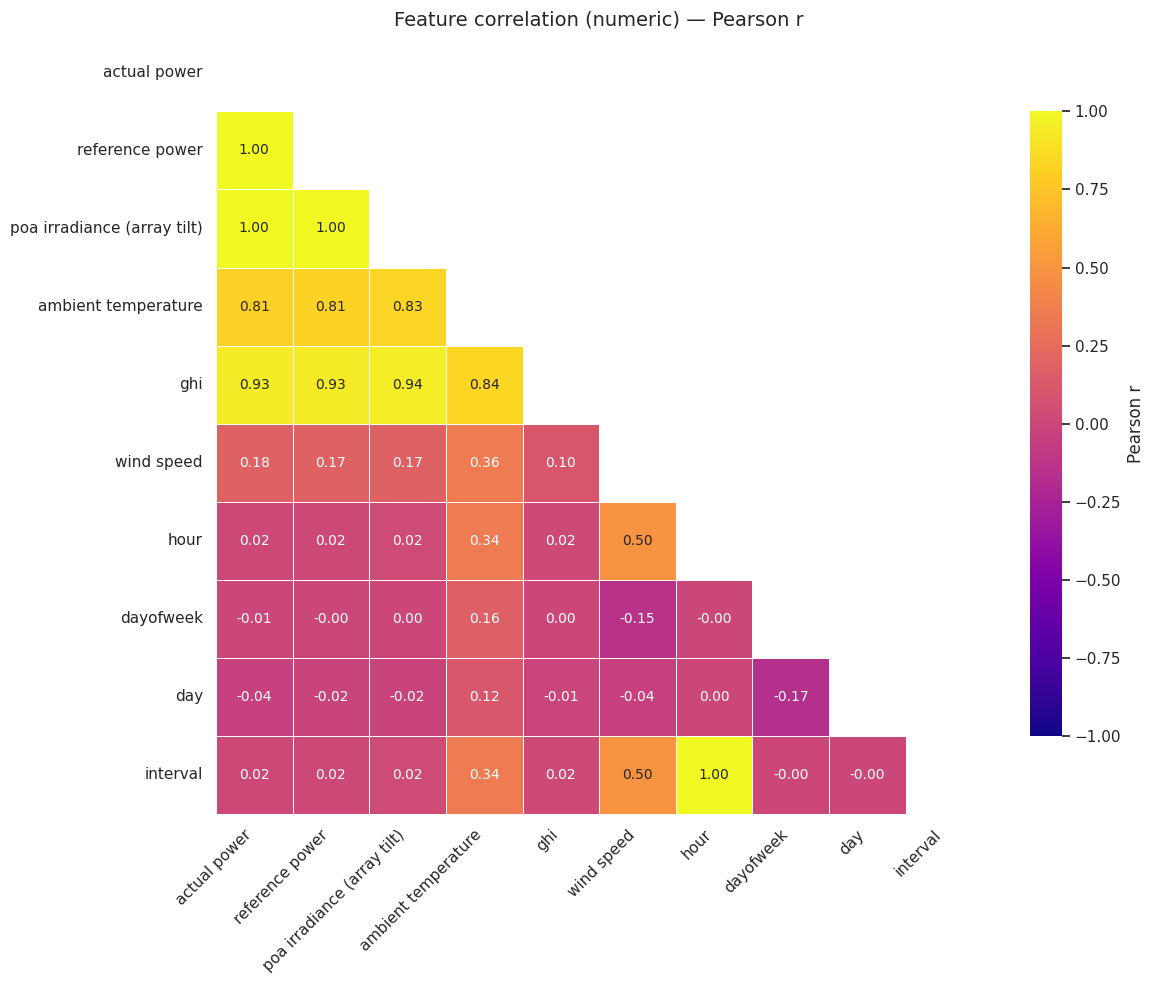

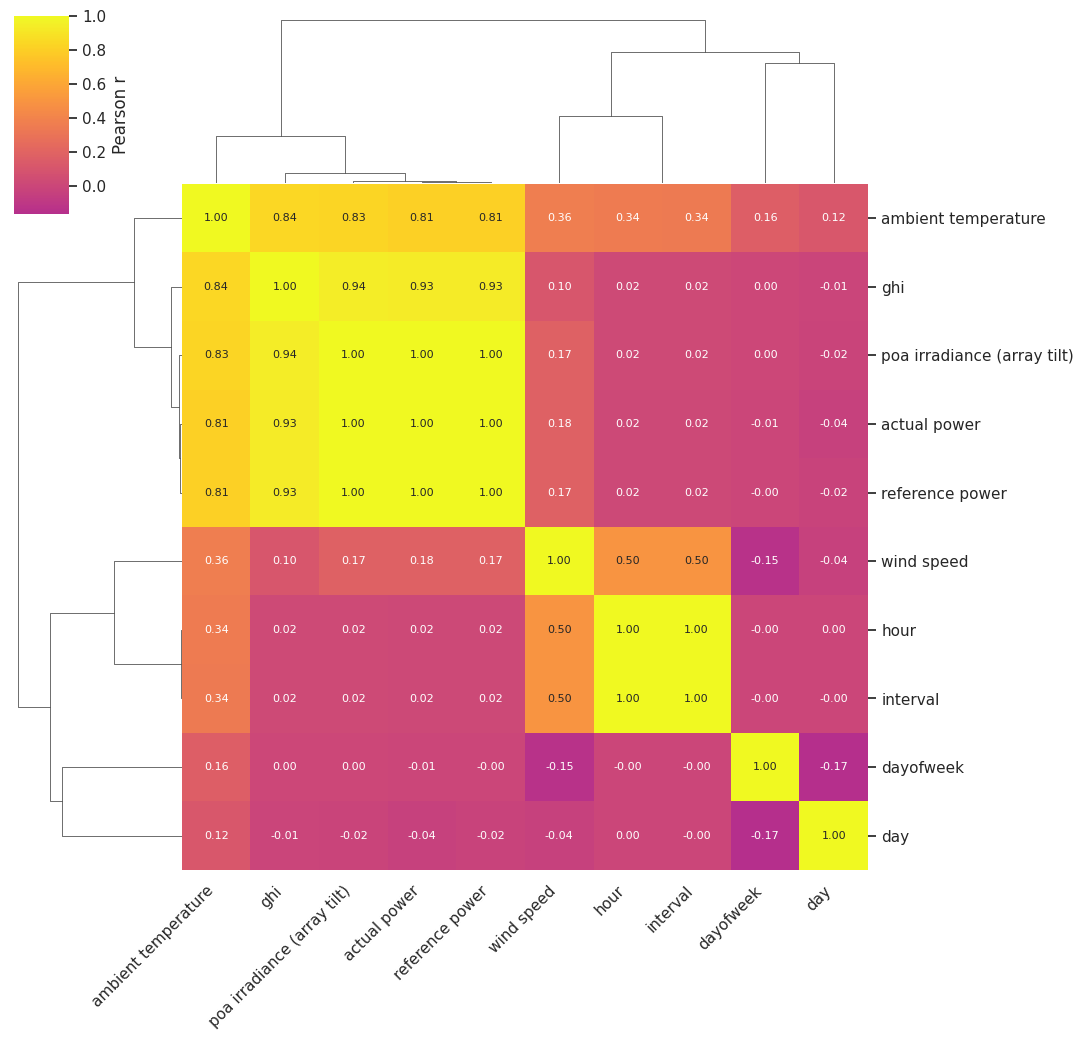

In [113]:
plot_correlation_heatmap(df_na)

Following insights:

- High correlation exists actual power and reference power. Consequently, when designing the model to predict actual power, it's crucial to exclude DC power from the features to prevent data leakage.

- The more there is sunlight the more power will be generated by the solar panels which is highlighted in the strong relation between actual and power generated and irradiation.

- Solar panels are consistently exposed to ambient temperature, explaining the correlation with the module temperature. Although module temperature tends to be higher during power generation.

- The relationship between temperature and sun irradiation is self-evident, requiring no further explanation.


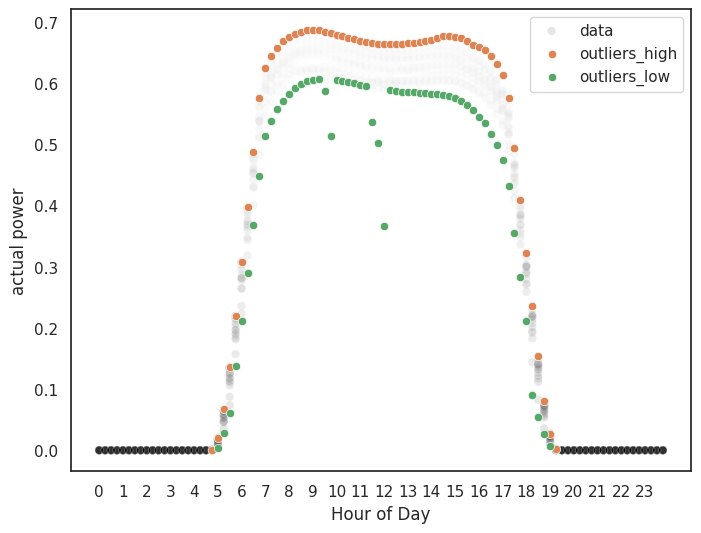

In [114]:
plot_outliers(df_na, "actual power")

- The plot indicates the presence of outliers in the features (considering the specified percentile threshold), these outliers include instances of null power generation values during daytime, which may be attributed to various factors such as measurement inaccuracies, shading, or inverter stopped for maintenance.

No data data imputation done

### Prepare data for trainning

In [115]:
data.index = pd.to_datetime(data.index.strftime('%d-%m-%Y %H:%M'), format='%d-%m-%Y %H:%M')

In [116]:
data_all = pd.concat([data.groupby(data.index).sum(numeric_only=True)[power_data.columns],
                       data.groupby(data.index).mean(numeric_only=True)[weather_data.columns]], axis=1)

# add datetime features
data_all['hour'] = data_all.index.hour
data_all['dayofweek'] = data_all.index.dayofweek
data_all['day'] = data_all.index.dayofyear
data_all['day'] = data_all.day.map({data_all.day.unique()[i-1]:i for i in range(1, DAYS+1)})
data_all['interval'] = data_all.index.time
data_all['interval'] = data_all.interval.map({unique_times[i-1]: i for i in range(1, len(unique_times)+1)})

The objective of this study is to forecast the solar generated power for the next day, specifically the actual power. Given the high correlation between actual and reference power (as demonstrated earlier), we have selected actual power as our target variable.

In [117]:
steps  = 96 # 24*4 (for each 15min intervall)
# shift all data by 1 day so that each features sample
# corresponds to the next day AC_POWER generated
target = data_all['actual power'].shift(-steps ).dropna()
features = data_all[~data_all['actual power'].shift(-steps).isna()]

In [118]:
power_features = power_data.columns
weather_features = weather_data.columns

In [119]:
# last 4 days will be reserved for testing
split_datetime = -steps * 4
x_train = features.iloc[:split_datetime]
x_test = features.iloc[split_datetime:]
y_train = target[:split_datetime]
y_test = target[split_datetime:]

Text(0, 0.5, 'AC Power')

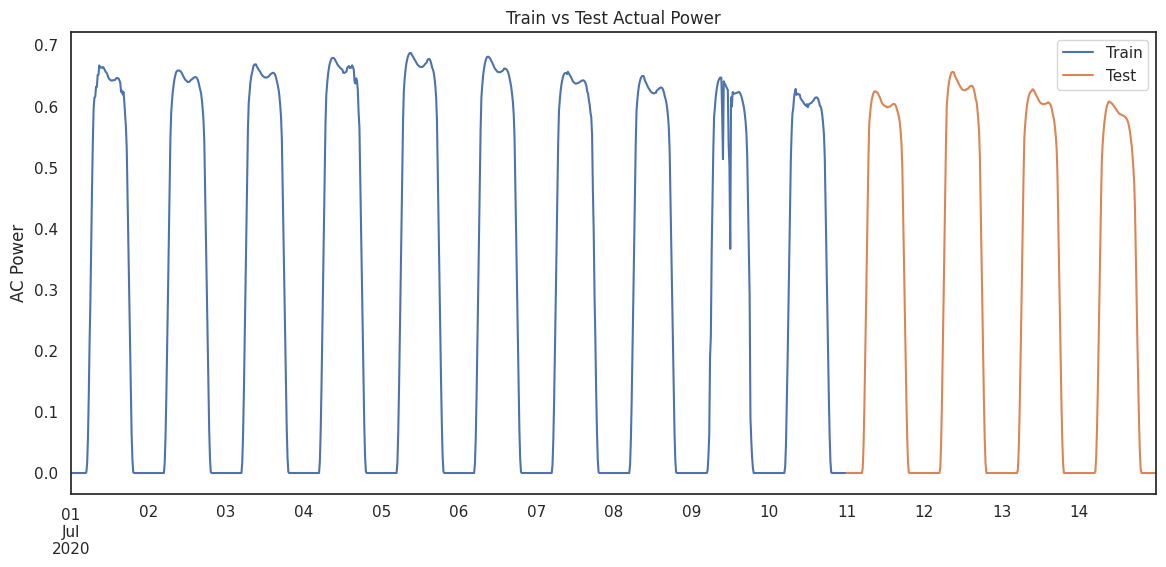

In [120]:
# Plot AC power training and testing date splits
_ = pd.DataFrame(y_train) \
    .rename(columns={'actual power': 'Train'}) \
    .join(pd.DataFrame(y_test).rename(columns={'actual power': 'Test'}), how='outer') \
    .plot(figsize=(14,6))

plt.title('Train vs Test Actual Power')
plt.ylabel('AC Power')

## Building ML Models

### 1- XGBoost :

In [121]:
XGBoostForecaster_model = XGBoostForecaster()

In [122]:
XGBoostForecaster_model.fit(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
    )

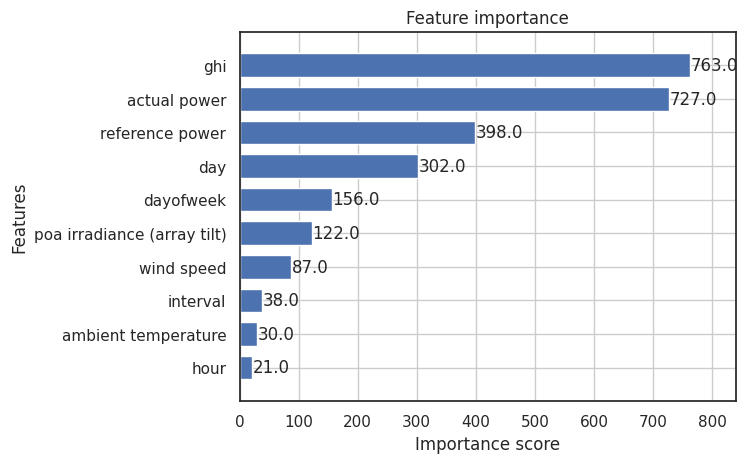

In [123]:
_ = XGBoostForecaster_model.plot_feature_importance()

In [124]:
predicted = XGBoostForecaster_model.predict(
    x=x_test
    )

In [125]:
results = XGBoostForecaster_model.evaluate(
    x_test=x_test,
    y_test=y_test,
    data_all=data_all,
    steps=steps
    )

In [126]:
xgb_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9669839806643179
MAE: 0.04507546108889795
RMSE: 0.051802795493879186


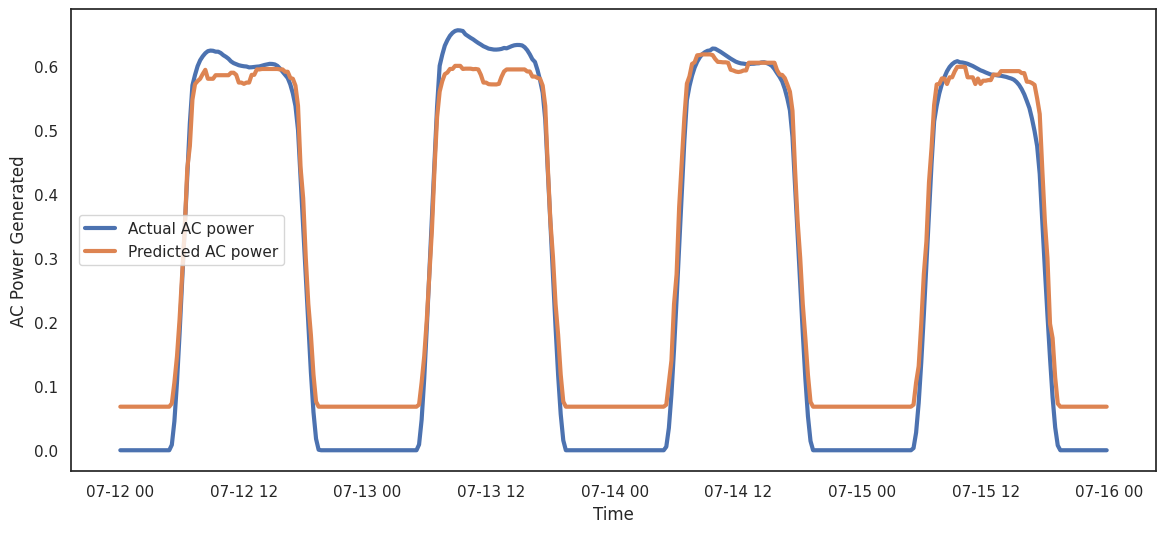

In [127]:
plot_predictions(results["Actual"], results["Predicted"])

#### Forecast Next Future Day

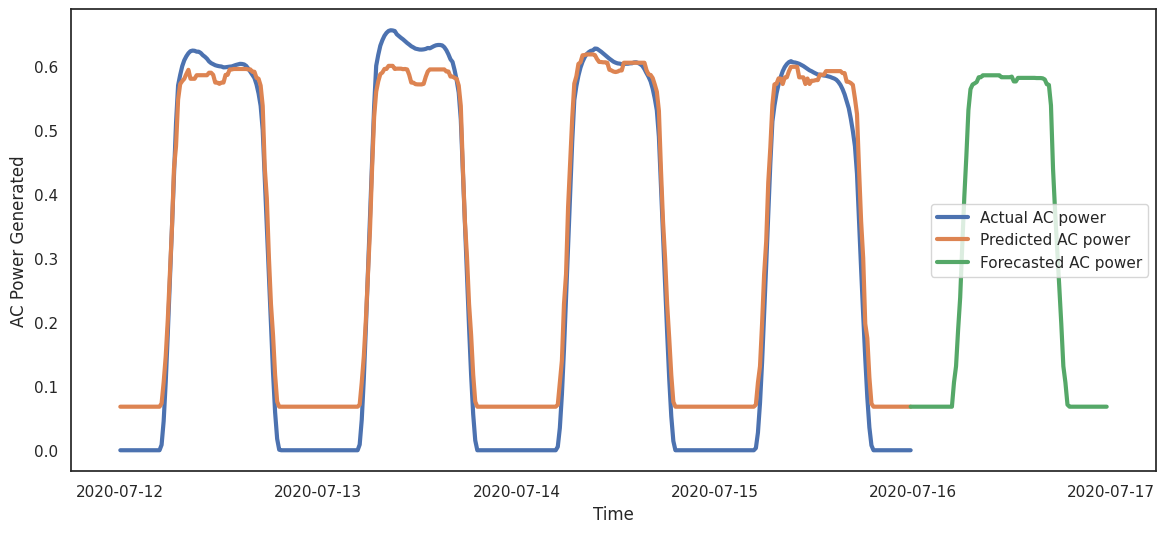

In [128]:
last_day = data_all["2020-07-15 00:00:00":]
last_day_pred = XGBoostForecaster_model.predict(x=last_day)
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)

#### Observations

After fine tuning the XGBoost hyperparameters by a trial and error method we see that the model demonstrates a relatively high R2 score (96%). However, upon examining the plot and assessing the MAE/RMSE error, it becomes evident that the model's predictions lack accuracy, particularly detecting an off-set. The model struggles to adapt to rapid fluctuations, resulting in underestimated values for the actual power. This pattern is observed not only in the current predictions but also extends to the next-day forecast.

### 2- Random Forest :

In [129]:
RandomForestForecaster_model = RandomForestForecaster()

In [130]:
RandomForestForecaster_model.fit(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
    )

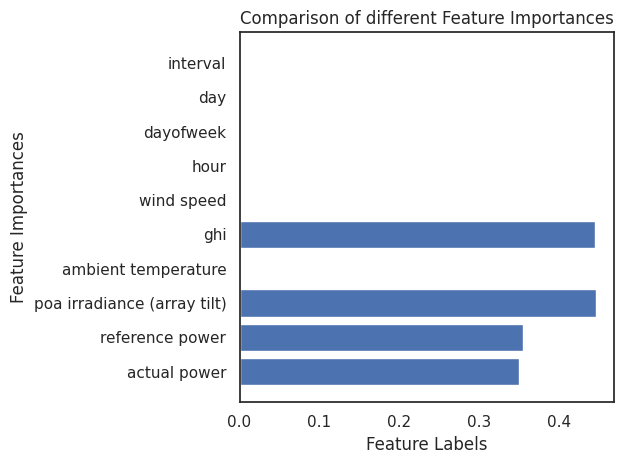

In [131]:
_ = RandomForestForecaster_model.plot_feature_importance()

In [132]:
predicted = RandomForestForecaster_model.predict(
    x=x_test
    )

In [133]:
results = RandomForestForecaster_model.evaluate(
    x_test=x_test,
    y_test=y_test,
    data_all=data_all,
    steps=steps
    )

In [134]:
rf_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9954262037893225
MAE: 0.0115338609461663
RMSE: 0.01928098633257167


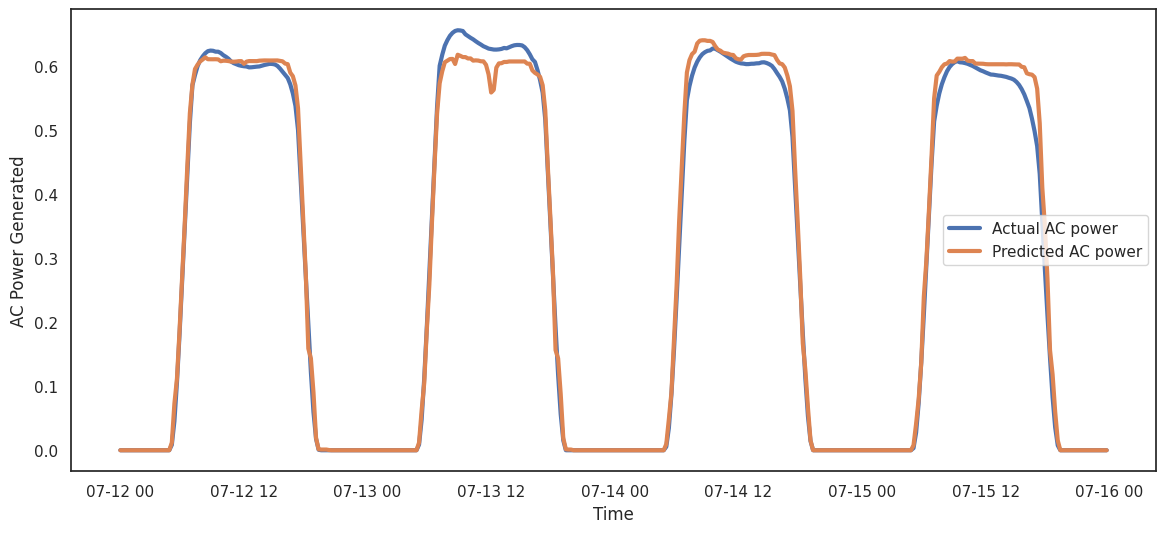

In [135]:
plot_predictions(results["Actual"], results["Predicted"])

#### Forecast Next Future Day

In [136]:
last_day_pred = RandomForestForecaster_model.predict(last_day)

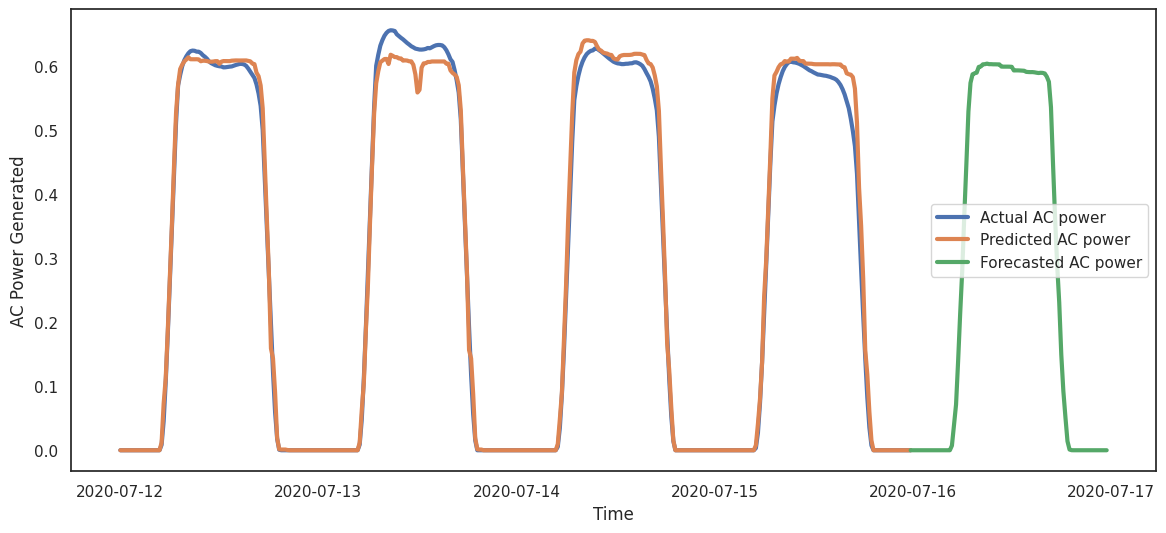

In [137]:
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)

#### Observations

The Random Forest model also gives a good R2 score (99%), albeit lower than that produced by the XGBoost model. Examining the plot reveals that, like the XGBoost model, the Random Forest model faces challenges in adapting to rapid fluctuations during the midday period. However, it does not exhibit as much underestimation of the generated power as the XGBoost modell.

Additionally, the features importance plot indicate that the model does not heavily consider the 15-minute interval of the day. Instead, it focuses on the actual and reference power generated in the previous days.

### 3- LTSM Model :

Both ML algorithms provided relatively accurate prediction results, but they encountered challenges in adapting to the fluctuations in generated power. Consequently, we have opted to explore a DL approach, specifically leveraging the capabilities of RNN and LSTM neural networks known for their effectiveness in forecasting based on past data. The chosen model is LSTM, and it's essential to acknowledge that training it poses a challenge due to the limited size of the dataset used in this study. The model might encounter difficulty capturing all the patterns connecting the AC power generated and the associated features.

For the LSTM network, the input will consist of power and weather measurements from the past three days. The network will be tasked with predicting the AC power generated at each 15-minute interval for the following day.

In [138]:
LSTMForecaster_model = LSTMForecaster()

#### 1- Data scaling

In [139]:
scaled_data = LSTMForecaster_model.scale_data(
    data=data_all
    )

#### 2- Construct Window Data

In [140]:
X_train, Y_train, X_test, Y_test = LSTMForecaster_model.create_lstm_data(
    data=scaled_data
    )

#### 3- Build & train LSTM

In [141]:
LSTMForecaster_model.fit(
    x_train=X_train,
    y_train=Y_train,
    x_test=X_test,
    y_test=Y_test
    )

/workspaces/solar_forecasting/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 384, 256)       │       273,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 384, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,392 (3.14 MB)

 Trainable params: 823,392 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

<Axes: >

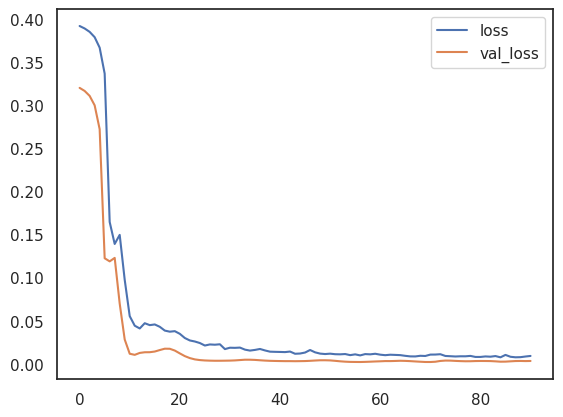

In [142]:
history = pd.DataFrame(LSTMForecaster_model.history.history)
history.plot()

In [143]:
predicted = LSTMForecaster_model.predict(
    x=X_test
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


In [144]:
results = LSTMForecaster_model.evaluate(
    scaled_data=scaled_data,
    data=data_all,
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


In [145]:
lstm_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9943701730348763
MAE: 0.015566430686967317
RMSE: 0.021391358443999507


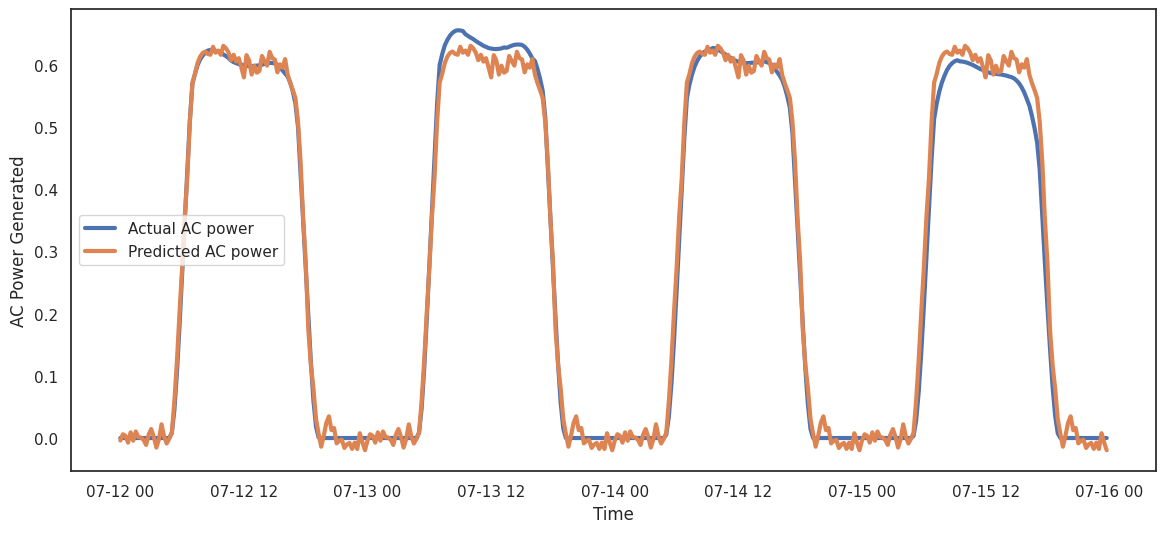

In [146]:
plot_predictions(results["Actual"], results["Predicted"])

#### Forecast Next Future Day

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


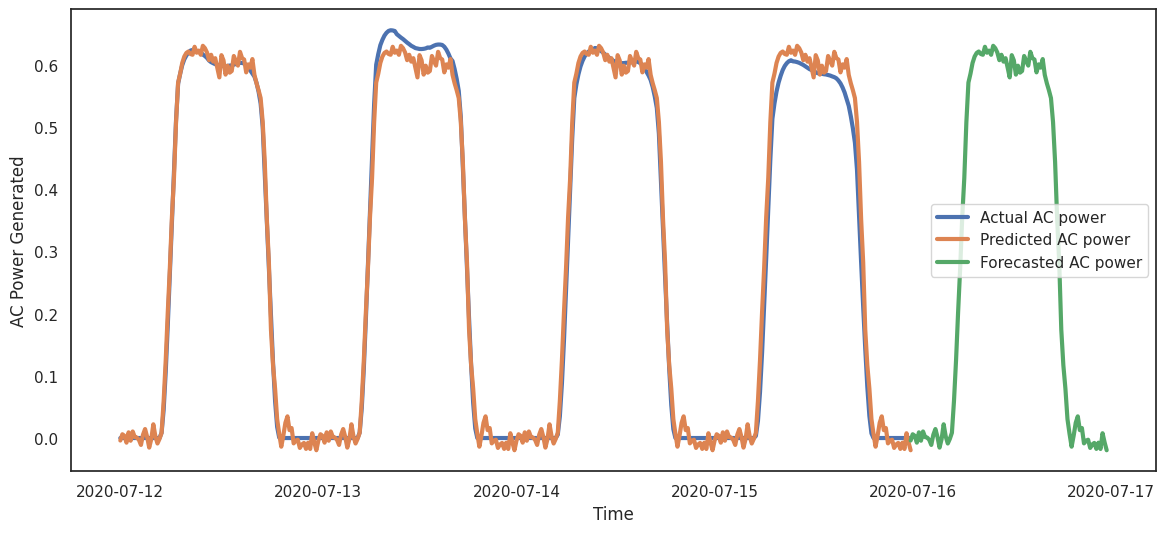

In [147]:
last_day = np.array(scaled_data)[-3*steps:, :]
last_day_arr = np.array([last_day])
future_day_pred = LSTMForecaster_model.predict(last_day_arr)
future_pred = LSTMForecaster_model.y_scaler.inverse_transform(future_day_pred.reshape(steps, 1)).reshape(-1)
plot_forecast_day(results["Actual"], results["Predicted"], future_pred)

#### Observations

As anticipated, the LSTM model faced limitations in learning from the restricted input data, resulting R2 score compared to the ML models (99%) and a MAE of 1.5%. The model consistently produced similar predictions for nearly every day. Additionally, it struggled to adapt to the rapid fluctuations in generated power. It's noteworthy that the model introduced minor fluctuations during nighttime, even though power generation should ideally be zero during those periods. These nighttime fluctuations, while present, can be disregarded as they are not critical for the prediction needs during those times.

### Final Results

In [148]:
stats = pd.DataFrame([xgb_errors, rf_errors, lstm_errors],
                     columns=["R2 score", "MAE", "RMSE"],
                     index=["XGBoost", "RandomForest", "LSTM"]
                     )
stats.head()

,R2 score,MAE,RMSE
XGBoost,0.966984,0.045075,0.051803
RandomForest,0.995426,0.011534,0.019281
LSTM,0.994370,0.015566,0.021391


### Conlusion

What insights can be drawn from our study?

The trained models demonstrated commendable performance across all metrics considered (R2 score, MAE, RMSE), with the XGBoost model achieving the highest R2 score of approximately 99%.

Despite its superior R2 score, the XGBoost model exhibited a drawback in underestimating the actual power, unlike the Random Forest and LSTM models, which provided closer predictions.

All trained models faced challenges in adapting to the rapid fluctuations in generated power, ultimately resulting in forecasts that averaged out generated power values.

The study highlights that the dataset's size, comprising only 15 days, is insufficient for the models to truly comprehend the relationship between variations in AC power generation and other power and weather measured from the preceding days. This limitation makes forecasting tasks notably challenging, as they typically require multiple years of data for a more comprehensive understanding.